## Module 4: 

## Team Members:
Isabella Imburgia and Zain Abed

## Project Title:
Resisting Apoptosis and Uterine Cancer 



## Project Goal:
This project seeks to examine the effects of resisting apoptosis on uterine corpus endometrial carcinoma. There are numerous questions that can be asked relating to this such as:
1. Do more aggressive UCEC histologic subtypes, which may reflect greater resistance to apoptosis, show worse survival outcomes?
2. Is tumor status associated with prognosis in UCEC?
3. Are demographic features linked to outcome difference in UCEC?

The main question that will be answered with the learning model is: Is it possible to predict histologic subtype based on genes relating to the hallmark resisting apoptosis, and what can that say about prognosis or overall survival?

## Disease Background:
*Pick a hallmark to focus on, and figure out what genes you are interested in researching based on that decision. Then fill out the information below.*

* Cancer hallmark focus: resisting apoptosis
* Overview of hallmark: In healthy tissue, apoptosis is controlled form of programmed cell death. It protects the body by eliminating cells with severe DNA damage, dangerous mutations, or abnormal growth signals. When this works, potentially cancerous cells are often destroyed before they can expand. Cancer cells become dangerous because they can learn to block or bypass apoptosis. That lets them survive when they should die. As a result, cells with harmful mutations can keep dividing, accumulate more changes, and form tumors.
* Genes associated with hallmark to be studied (you can point to a CSV with the list of genes you will study, or point to a citation with a gene signature of interest) C:\Users\ajq2af\OneDrive - University of Virginia\Documents\UVA\BME 2315\Module-4-Cancer-Imburgia-Abed\code\Menyhart_JPA_CancerHallmarks_core.txt

### Uterine Corpus Endometrial Carcinoma 

* Prevalence & incidence 

Uterine cancer is the most common form of gynecologic cancer in the United States. There have been 69,120 new cases reported in the US in 2025 with an incidence of approximately 28.3 per 100,000 women. There were 13,860 deaths from this form of cancer in 2025. 
* Risk factors (genetic, lifestyle) & Societal determinants

Uterine cancer is most commonly caused by a hormone imbalance, specifically in this case prolonged estrogen exposure. Risk factors include obesity, type 2 diabetes, irregular onset of menopause, polycystic ovary syndrome (PCOS), and other metabolic conditions. The American Cancer Society reports that there are societal factors with Black women dying of endometrial cancer at nearly twice the rate of white women. There is also a higher mortality rate in non-Hispanic Black women and this disparity is thought to be caused by a lack of accessible healthcare in rural or low-income areas. 

* Standard of care treatments (& reimbursement) 

For early stage uterine or endometrial cancer, the treatment is normally a full hysterectomy to completely remove the uterus and the cancer. If the cancer has progressed, then chemotherapy or radiation may be necessary. There are a limited number of FDA approved drugs to treat advanced or recurring endometrial carcinoma and reibursement for these treatments depends on the type of drug and the stage of cancer, it is not a national standard covered by Medicare. 


* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology)

Biologically, uterine corpus endometrial carcinoma (UCEC) develops from the endometrium, the hormonally responsive inner lining of the uterus, where normal cell growth and shedding are regulated by estrogen and progesterone. When the endometrium is exposed to prolonged unopposed estrogen, it can become hyperplastic and, over time, progress to malignancy, especially in endometrioid tumors, which are often considered Type 1 and are more hormone-related. In contrast, Type 2 tumors, such as serous endometrial adenocarcinoma, are typically less hormone-driven and more aggressive. At the cellular and molecular level, UCEC develops when normal controls over proliferation, DNA damage response, and cell death break down. One important cancer hallmark in this disease is resisting apoptosis, meaning tumor cells avoid the programmed cell death that would normally eliminate abnormal or damaged cells. This can happen through disruption of pathways involving p53, PI3K/AKT, and other regulators of survival signaling, allowing malignant cells to persist, accumulate further changes, and become more resistant to treatment.
https://www.cancer.gov/types/uterine/hp/endometrial-treatment-pdq
https://www.cancer.org/cancer/types/endometrial-cancer/about/key-statistics.html 

## Data-Set: 

*ChatGPT was used to help improve clarity and check for errors in writing and spelling.*
*OpenAI. (2026). ChatGPT (GPT-5 mini) [Large language model]. [https://openai.com/chatgpt](https://openai.com/chatgpt)*

The dataset comes from The Cancer Genome Atlas RNA-seq dataset, which was reprocessed by Rahman et al., who used DNA and RNA sequencing to obtain molecular data on the 11,000 tumor samples collected. The tumor samples were then subsetted by Professor Groves to include 50–100 tumor samples for each respective cancer type. The metadata regarding patients was also reduced to roughly 20 columns out of the original 526 to focus on the categories best suited for this project.

As stated earlier, the goal of the project is to examine the effects of resisting apoptosis on UCEC. To do this, we will examine the molecular data of tumors from UCEC patients, specifically looking at the levels of tumor suppressors such as p53 and PI3K/AKT, which in this dataset are measured using log-transformed TPM values. Additionally, in order to answer our follow-up questions, the metadata needs to be analyzed. For the first two, we need to examine the histological diagnosis of the tumors along with the disease-free interval (DFI), the progression-free interval (PFI), and overall survival (OS), all of which are measured in months. For the third question, along with OS, PFI, and DFI, we would like to examine race to determine if there is variability in outcomes between demographics.



## Data Analysis

In [3]:
#Claude was used to assist with code debugging and error diagnosis. Anthropic. (2026). Claude (Claude Sonnet 4.6) [Large language model]. https://claude.ai

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
 
# ── Load the data ──────────────────────────────────────────────────────────────
data = pd.read_csv(
    '/Users/zain/Documents/GitHub/Module-4-Cancer-Imburgia-Abed/data/TRAINING_SET_GSE62944_subsample_log2TPM.csv',
    #'/Users/ajq2af/OneDrive - University of Virginia\Documents/UVA/BME 2315/Module-4-Cancer-Imburgia-Abed/data/TRAINING_SET_GSE62944_subsample_log2TPM.csv',
    index_col=0, header=0
)
metadata_df = pd.read_csv(
    '/Users/zain/Documents/GitHub/Module-4-Cancer-Imburgia-Abed/data/TRAINING_SET_GSE62944_metadata.csv',
    #'/Users/ajq2af/OneDrive - University of Virginia/Documents/UVA/BME 2315/Module-4-Cancer-Imburgia-Abed/data/TRAINING_SET_GSE62944_metadata.csv',
    index_col=0, header=0
)
 
# ── Explore the data ───────────────────────────────────────────────────────────
print(data.shape)
print(data.info())
print(data.describe())
 
# ── Explore the metadata ───────────────────────────────────────────────────────
print(metadata_df.info())
print(metadata_df.describe())
 
# ── Subset data for a specific cancer type ─────────────────────────────────────
cancer_type = 'UCEC'
 
# Strip whitespace to avoid silent mismatches
data.columns = data.columns.str.strip()
metadata_df.index = metadata_df.index.str.strip()
 
# Get sample IDs for the target cancer type
cancer_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
common_samples = data.columns.intersection(cancer_samples)
print(cancer_samples)
 
# Subset the main data to include only UCEC samples
UCEC_data = data[common_samples]

(15716, 1802)
<class 'pandas.core.frame.DataFrame'>
Index: 15716 entries, A1BG to ZZZ3
Columns: 1802 entries, TCGA-E9-A1NI-01A-11R-A14D-07 to TCGA-ND-A4WC-01A-21R-A28V-07
dtypes: float64(1802)
memory usage: 216.2+ MB
None
       TCGA-E9-A1NI-01A-11R-A14D-07  TCGA-E2-A1LK-01A-21R-A14D-07  \
count                  15716.000000                  15716.000000   
mean                       3.819608                      3.695116   
std                        2.367493                      2.448152   
min                        0.000000                      0.000000   
25%                        1.936472                      1.630385   
50%                        3.906571                      3.775523   
75%                        5.435952                      5.426145   
max                       12.964224                     14.202553   

       TCGA-BH-A0B2-01A-11R-A10J-07  TCGA-E2-A107-01A-11R-A10J-07  \
count                  15716.000000                  15716.000000   
mean              

First, the expression matrix and accompanying patient metadata are read and then  their dimensions and basic statistics are explored to confirm successful loading. To focus the analysis on uterine corpus endometrial carcinoma (UCEC), the dataset is filtered to only include samples labeled as UCEC in the metadata. This reduces the dataset from the full multi-cancer cohort to only the relevant tumor samples, allowing for the examination of apoptosis-related gene expression specifically within this cancer type.

In [4]:
# ── Gene subsetting ────────────────────────────────────────────────────────────
desired_gene_list = ['CASP1','CASP2','CASP3','CASP5','CASP6','CASP7','CASP8','CASP9','CASP10','BCL2','BCL2L1','BCL2L2','BCL2L10','BCL2A1','BCL2L11','BAX','BAK1','BAD','BID','BBC3','BNIP3','BNIP3L','MCL1','TNF','FAS','FADD','TRADD','TNFRSF1A','TNFRSF1B','TNFSF10','TNFRSF10A','TNFRSF10B','TNFRSF10C','TNFRSF10D','CFLAR','NFKB1','RELA','NFKBIA','IKBKB','CHUK','TRAF2','TRAF6','MAP3K7','TAB1','AKT1','AKT2','AKT3','PIK3CA','PIK3R1','PTEN','MTOR','GSK3B','RICTOR','SOS1','TP53','MDM2','MDM4','ATM','CHEK1','CHEK2','CDKN1A','CDKN2A','RB1','EP300','MAPK1','MAPK3','MAPK8','MAPK9','MAPK10','MAPK12','MAPK13','MAPK14','RAF1','BRAF','MAP2K1','MAP2K2','MAP2K3','MAP2K4','MAP2K7','STAT1','STAT3','STAT5A','JAK1','JAK2','JAK3','SOCS3','IL6R','XIAP','BIRC2','BIRC3','BIRC5','APAF1','CYCS','DIABLO','AIFM1','RIPK1','RIPK2','BCL10','TP73','HIF1A','MAPKAPK2']
gene_list = [g for g in desired_gene_list if g in UCEC_data.index]
 
for gene in desired_gene_list:
    if gene not in gene_list:
        print(f"Warning: {gene} not found in the dataset.")
 
# .loc[] subsets by index label; .iloc[] subsets by integer position
UCEC_gene_data = UCEC_data.loc[gene_list]  # uses validated gene_list (safe)
print(UCEC_gene_data.head())
 
# ── Basic statistics on subsetted gene data ────────────────────────────────────
print(UCEC_gene_data.describe())
print(UCEC_gene_data.var(axis=1))     # Variance of each gene across samples
print(UCEC_gene_data.mean(axis=1))    # Mean expression per gene
print(UCEC_gene_data.median(axis=1))  # Median expression per gene

       TCGA-SL-A6J9-01A-11R-A31O-07  TCGA-AX-A3G9-01A-11R-A22K-07  \
CASP1                      5.936625                      1.639916   
CASP2                      3.515471                      4.883680   
CASP3                      5.022855                      5.335578   
CASP5                      0.609728                      0.000000   
CASP6                      5.113405                      5.851049   

       TCGA-AJ-A3BH-01A-11R-A19W-07  TCGA-EY-A212-01A-11R-A14M-07  \
CASP1                      3.924611                      3.537996   
CASP2                      5.863319                      5.284364   
CASP3                      5.805952                      4.846592   
CASP5                      0.412746                      0.266397   
CASP6                      5.688445                      4.972724   

       TCGA-AJ-A8CV-01A-11R-A37O-07  TCGA-BG-A0LW-01A-11R-A16W-07  \
CASP1                      4.763923                      3.618829   
CASP2                      4.625

Rather than analyzing all genes in the dataset, it is narrowed to focus on a curated list of approximately 100 genes known to be involved in apoptosis regulation, survival signaling, and DNA damage response. This gene selection is directly related to the hallmark of interest, resisting apoptosis, and is relevant to the molecular methods of UCEC and each subtype.

Average OS time for UCEC: 1091.66
                                 CASP1     CASP2     CASP3     CASP5  \
TCGA-SL-A6J9-01A-11R-A31O-07  5.936625  3.515471  5.022855  0.609728   
TCGA-AX-A3G9-01A-11R-A22K-07  1.639916  4.883680  5.335578  0.000000   
TCGA-AJ-A3BH-01A-11R-A19W-07  3.924611  5.863319  5.805952  0.412746   
TCGA-EY-A212-01A-11R-A14M-07  3.537996  5.284364  4.846592  0.266397   
TCGA-AJ-A8CV-01A-11R-A37O-07  4.763923  4.625959  5.601612  0.174364   

                                 CASP6     CASP7     CASP8     CASP9  \
TCGA-SL-A6J9-01A-11R-A31O-07  5.113405  4.939362  3.405167  4.077915   
TCGA-AX-A3G9-01A-11R-A22K-07  5.851049  5.336148  4.773844  4.239560   
TCGA-AJ-A3BH-01A-11R-A19W-07  5.688445  4.321128  5.192003  4.011833   
TCGA-EY-A212-01A-11R-A14M-07  4.972724  4.756785  4.260495  4.596142   
TCGA-AJ-A8CV-01A-11R-A37O-07  6.653002  4.875722  4.540117  4.557995   

                                CASP10      BCL2  ...  \
TCGA-SL-A6J9-01A-11R-A31O-07  2.157104  1.0

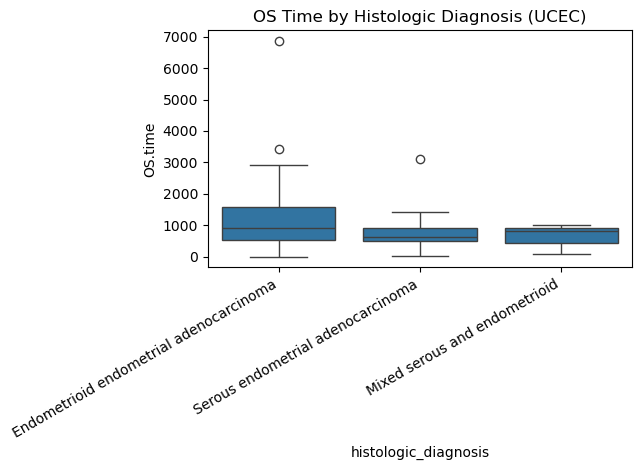

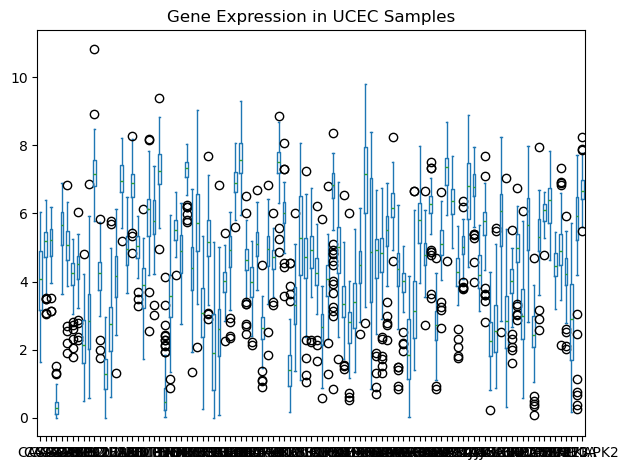

In [5]:
# ── Survival time summary for UCEC ────────────────────────────────────────────
metadata_df['OS.time'] = pd.to_numeric(metadata_df['OS.time'], errors='coerce')
filtered_df = metadata_df[metadata_df['cancer_type'] == cancer_type]
avg_OStime = filtered_df['OS.time'].mean()
print(f"Average OS time for {cancer_type}: {avg_OStime:.2f}")
 
# ── Merge expression data with metadata ───────────────────────────────────────
# Transpose so rows = samples, columns = genes
gene_df = UCEC_gene_data.transpose()  # shape: (num_samples, num_genes)
UCEC_metadata = metadata_df.loc[common_samples]  # align to common_samples
UCEC_merged = gene_df.merge(UCEC_metadata, left_index=True, right_index=True)
print(UCEC_merged.head())
 
# ── Plotting ───────────────────────────────────────────────────────────────────
# Boxplot: histological diagnosis vs. OS time (Seaborn)
plt.figure()
sns.boxplot(
    data=UCEC_merged,
    x='histologic_diagnosis',
    y='OS.time'
)
plt.title(f"OS Time by Histologic Diagnosis ({cancer_type})")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()
 
# Boxplot: TP53 and AKT1 expression in UCEC samples (Pandas)
available_genes = [g for g in ['CASP1','CASP2','CASP3','CASP5','CASP6','CASP7','CASP8','CASP9','CASP10','BCL2','BCL2L1','BCL2L2','BCL2L10','BCL2A1','BCL2L11','BAX','BAK1','BAD','BID','BBC3','BNIP3','BNIP3L','MCL1','TNF','FAS','FADD','TRADD','TNFRSF1A','TNFRSF1B','TNFSF10','TNFRSF10A','TNFRSF10B','TNFRSF10C','TNFRSF10D','CFLAR','NFKB1','RELA','NFKBIA','IKBKB','CHUK','TRAF2','TRAF6','MAP3K7','TAB1','AKT1','AKT2','AKT3','PIK3CA','PIK3R1','PTEN','MTOR','GSK3B','RICTOR','SOS1','TP53','MDM2','MDM4','ATM','CHEK1','CHEK2','CDKN1A','CDKN2A','RB1','EP300','MAPK1','MAPK3','MAPK8','MAPK9','MAPK10','MAPK12','MAPK13','MAPK14','RAF1','BRAF','MAP2K1','MAP2K2','MAP2K3','MAP2K4','MAP2K7','STAT1','STAT3','STAT5A','JAK1','JAK2','JAK3','SOCS3','IL6R','XIAP','BIRC2','BIRC3','BIRC5','APAF1','CYCS','DIABLO','AIFM1','RIPK1','RIPK2','BCL10','TP73','HIF1A','MAPKAPK2'] if g in UCEC_merged.columns]
UCEC_merged[available_genes].plot.box()
plt.title(f"Gene Expression in {cancer_type} Samples")
plt.tight_layout()
plt.show()

The basic descriptive statistics are computed for each gene across all UCEC samples, including variance, mean, and median expression levels. High variance genes indicate genes whose expression differs meaningfully across patients and may be relevant to distinguishing subtypes. The average overall survival (OS) time for UCEC patients in this dataset was calculated as an initial look at prognosis. OS time is measured in days and represents one of the primary outcome variables for evaluating whether molecular subtypes are associated with survival differences. To enable combined analysis of gene expression and clinical outcomes, the expression data with patient metadata on sample ID is merged. The resulting dataframe contains both gene expression values and clinical variables such as histologic diagnosis, OS time, and demographic information for each patient. This boxplot compares overall survival time across the three histologic subtypes present in our UCEC cohort: endometrioid endometrial adenocarcinoma, serous endometrial adenocarcinoma, and mixed serous and endometrioid. If more aggressive subtypes, such as serous, show shorter OS times, this would support the hypothesis that greater resistance to apoptosis is associated with worse survival outcomes. The second box plot visualizes the expression distributions of all the genes in the gene list. Differences in their expression levels across samples reflect the variability in apoptotic signaling within the cohort.

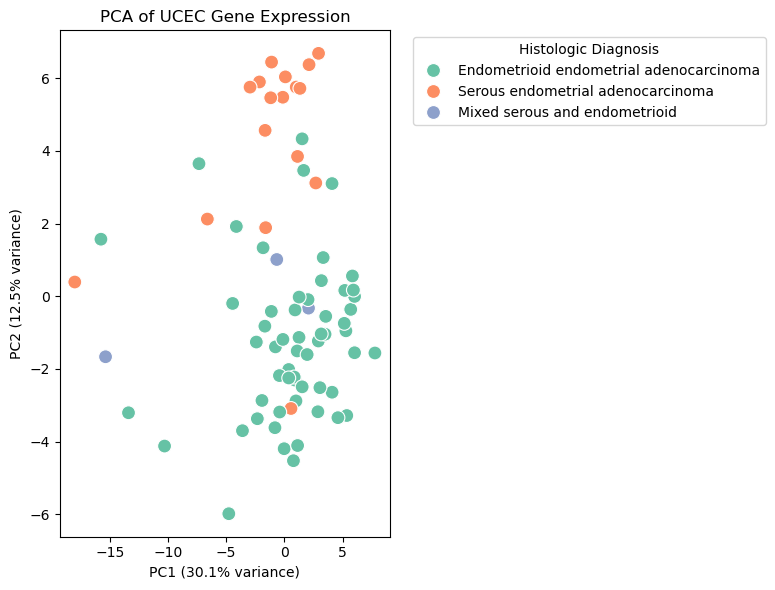

In [6]:
import pandas as pd # Pandas
import numpy as np # Numpy
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
import seaborn as sns
from sklearn.decomposition import PCA
# ── Prepare samples × genes matrix and attach metadata ───────────────────────
# Transpose so rows = samples, columns = genes
df = UCEC_gene_data.T.copy()  # shape: samples × genes

# Merge histologic_diagnosis from metadata into df
df = df.join(metadata_df[['histologic_diagnosis']], how='left')
# ── Remove samples with missing histologic_diagnosis ─────────────────────────  <-- ADD HERE
df = df.dropna(subset=['histologic_diagnosis'])
df = df[df['histologic_diagnosis'].str.strip() != '']

# ── PCA ───────────────────────────────────────────────────────────────────────
X = df[gene_list].values  # samples × genes, numeric only

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

explained = pca.explained_variance_ratio_ * 100  # percentage

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df['histologic_diagnosis'],
    palette="Set2",
    s=100
)
plt.title("PCA of UCEC Gene Expression")
plt.xlabel(f"PC1 ({explained[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({explained[1]:.1f}% variance)")
plt.legend(title="Histologic Diagnosis", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Principal Component Analysis was used to visualize overall variation in apoptosis-related gene expression across UCEC samples. The PCA plot showed partial separation between histologic subtypes, with serous endometrial adenocarcinoma samples tending to group in a different region than many endometrioid samples. The first two principal components explained 30.1% and 12.5% of the variance, totaling 42.6%. This indicates that the apoptosis-related gene panel captures meaningful molecular variation, but the overlap between groups suggests that histologic subtypes are not completely separable using only the first two principal components. Overall, the PCA results support the idea that apoptosis-related gene expression is associated with UCEC subtype, while also showing that the subtypes share overlapping molecular features.

/opt/anaconda3/lib/python3.13/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


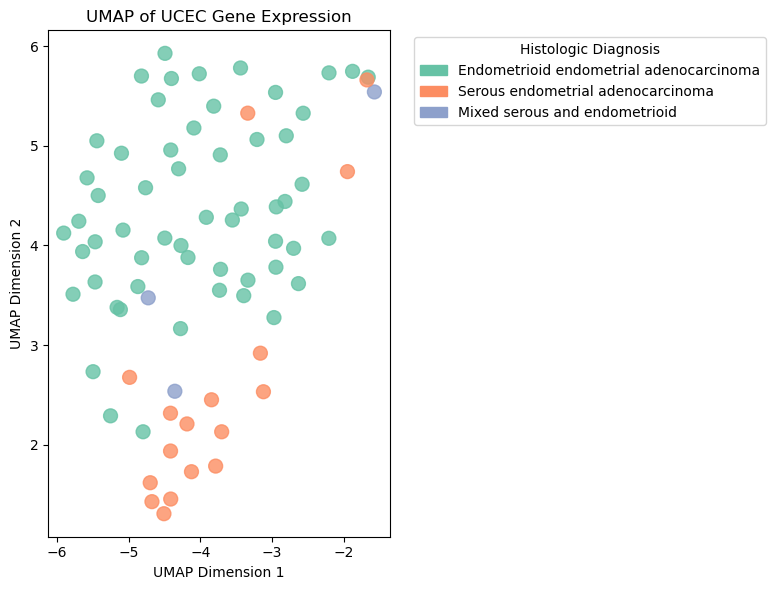

In [7]:
from sklearn.preprocessing import StandardScaler
import umap
import matplotlib.patches as mpatches

scaled_data = StandardScaler().fit_transform(X)

reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1, random_state=42)
X_umap = reducer.fit_transform(scaled_data)

# Color by histologic_diagnosis 
diagnoses = df['histologic_diagnosis']
categories = diagnoses.unique()
palette = sns.color_palette("Set2", len(categories))
color_map = dict(zip(categories, palette))
colors = diagnoses.map(color_map)

plt.figure(figsize=(8, 6))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=colors, s=100, alpha=0.8)

# Legend
handles = [mpatches.Patch(color=color_map[d], label=d) for d in categories]
plt.legend(handles=handles, title="Histologic Diagnosis", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("UMAP Dimension 1")
plt.ylabel("UMAP Dimension 2")
plt.title("UMAP of UCEC Gene Expression")
plt.tight_layout()
plt.show()

UMAP was used as a non-linear dimensionality reduction method to further examine structure in the apoptosis-related gene expression data. The UMAP visualization was generally consistent with the PCA results, showing partial separation between serous and endometrioid UCEC samples. Serous samples tended to occupy a different region of the plot, while endometrioid samples were more widely distributed. This suggests that apoptosis-related gene expression patterns contain information related to histologic subtype. However, the lack of completely distinct clusters indicates that the subtypes overlap molecularly and may not be fully separable based on this gene panel alone. The UMAP results support the interpretation that UCEC histologic subtypes may exist along a molecular spectrum rather than as sharply defined groups

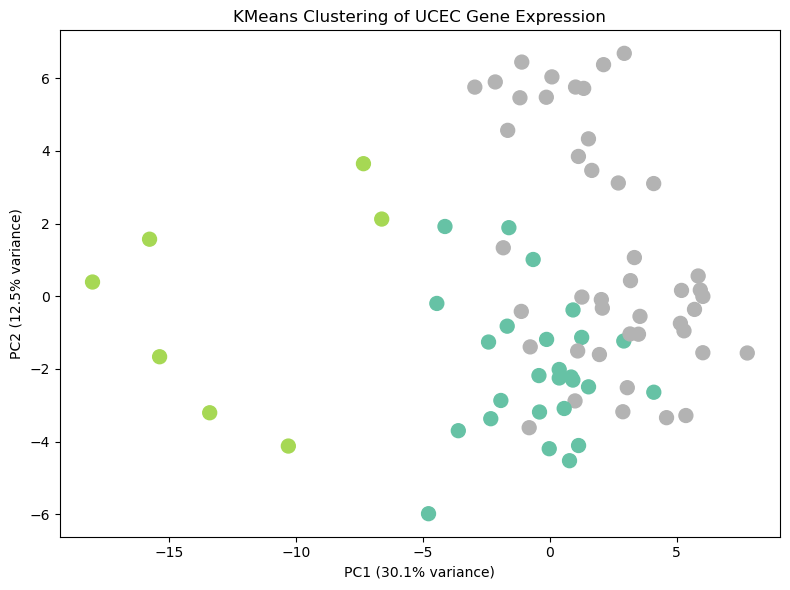

In [8]:
model = KMeans(n_clusters=3, random_state=0)
model.fit(X)
y_pred = model.predict(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_pred, cmap="Set2", s=100)
plt.xlabel(f"PC1 ({explained[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({explained[1]:.1f}% variance)")
plt.title("KMeans Clustering of UCEC Gene Expression")
plt.tight_layout()
plt.show()

To identify potential molecular subgroups in an unsupervised manner, we apply KMeans clustering with k=3, corresponding to the three known histologic subtypes. KMeans partitions samples into clusters by minimizing the within-cluster sum of squared distances, iteratively assigning points to the nearest centroid. We visualize the resulting clusters on the PCA plot to assess how well they align with known diagnoses. KMeans identifies three spatially distinct regions on the PCA plot. However, the cluster boundaries do not perfectly align with histologic diagnoses, particularly in the central overlap zone where endometrioid and serous samples intermix. This is expected because KMeans assumes spherical, equal-sized clusters, which may not reflect the true geometry of biological subtypes. The left cluster most closely corresponds to serous samples, while the larger right cluster captures the bulk of endometrioid samples.

Samples — Endometrioid: 57, Serous: 17


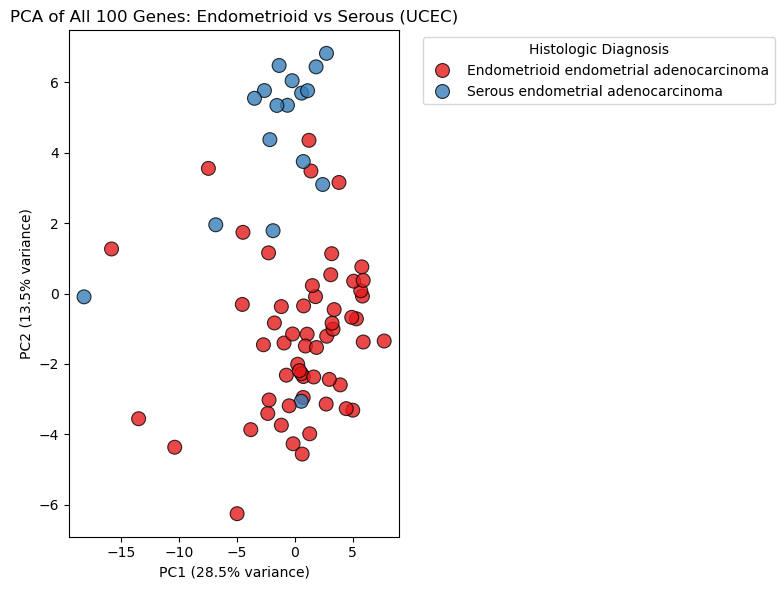

Logistic Regression Accuracy (all genes): 1.000


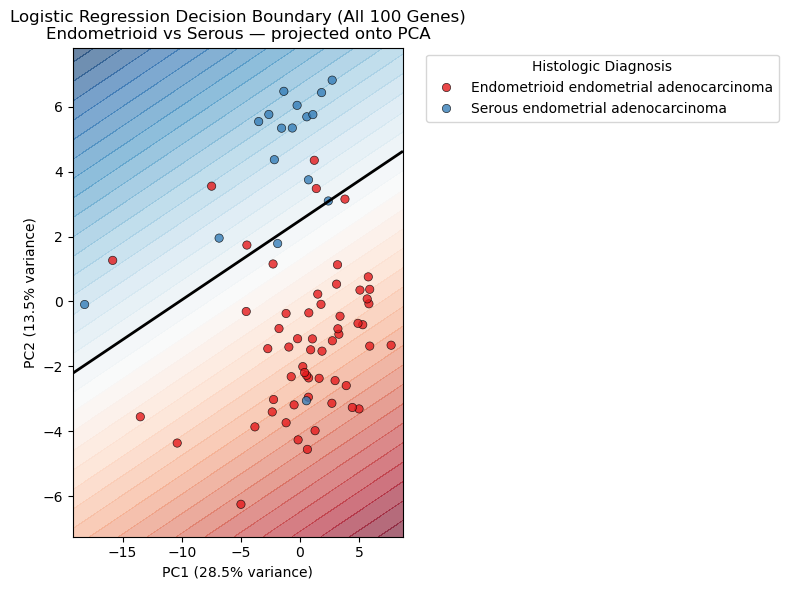

Decision Tree Accuracy (all genes): 1.000


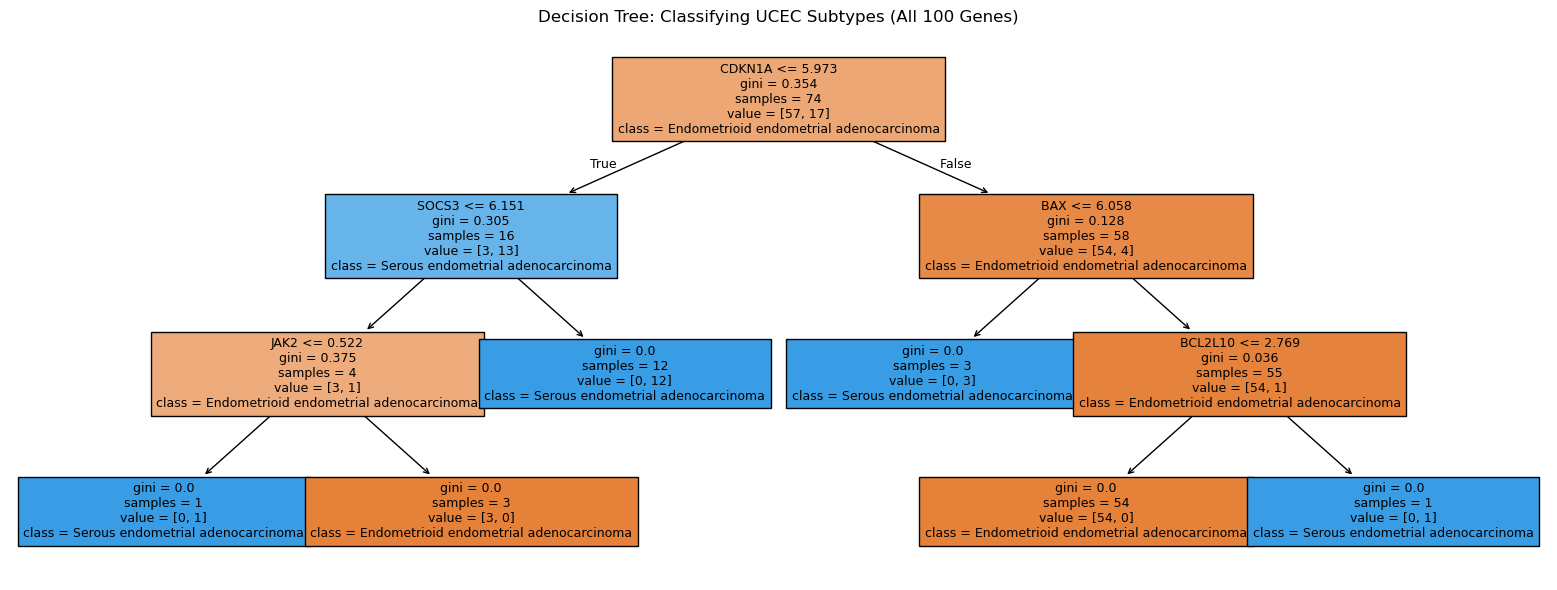

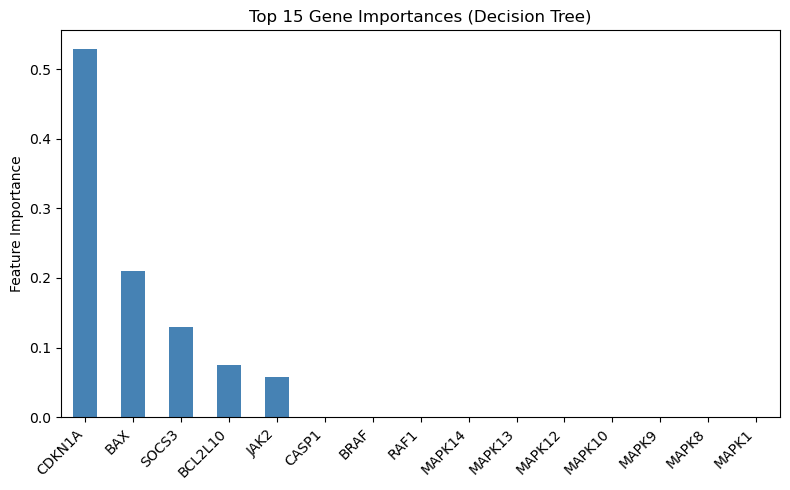

In [9]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder

# %%
# Use your already-loaded UCEC merged data
# X = gene expression features, y = histologic diagnosis labels

# ── Filter to binary classification (Endometrioid vs Serous) ──────────────────
binary_df = UCEC_merged[
    UCEC_merged['histologic_diagnosis'].isin([
        'Endometrioid endometrial adenocarcinoma',
        'Serous endometrial adenocarcinoma'
    ])
].copy()

# Only keep genes that are actually present in binary_df columns
available_genes = [g for g in gene_list if g in binary_df.columns]

# Encode labels: Endometrioid = 0, Serous = 1
le = LabelEncoder()
y = le.fit_transform(binary_df['histologic_diagnosis'])
y_label = list(binary_df['histologic_diagnosis'])
print(f"Samples — Endometrioid: {(y==0).sum()}, Serous: {(y==1).sum()}")

# ── Feature matrix: all 100 genes ─────────────────────────────────────────────
X_all = binary_df[available_genes].values

# ── PCA for visualization 
pca_vis = PCA(n_components=2)
X_vis = pca_vis.fit_transform(X_all)
explained_vis = pca_vis.explained_variance_ratio_ * 100

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x=X_vis[:, 0],
    y=X_vis[:, 1],
    hue=y_label,
    palette="Set1",
    s=100,
    edgecolors='k',
    alpha=0.8
)
plt.xlabel(f"PC1 ({explained_vis[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_vis[1]:.1f}% variance)")
plt.title("PCA of All 100 Genes: Endometrioid vs Serous (UCEC)")
plt.legend(title="Histologic Diagnosis", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ── Logistic Regression on all 100 genes ──────────────────────────────────────
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

lr_model = LogisticRegression(penalty=None, max_iter=1000).fit(X_scaled, y)
print(f"Logistic Regression Accuracy (all genes): {lr_model.score(X_scaled, y):.3f}")

# Plot decision boundary projected onto PC1/PC2
xx, yy = np.meshgrid(
    np.linspace(X_vis[:, 0].min() - 1, X_vis[:, 0].max() + 1, 300),
    np.linspace(X_vis[:, 1].min() - 1, X_vis[:, 1].max() + 1, 300)
)

# Project grid back to gene space via inverse PCA, then scale, then predict
grid_gene_space = pca_vis.inverse_transform(np.c_[xx.ravel(), yy.ravel()])
grid_scaled = scaler.transform(grid_gene_space)
Z = lr_model.decision_function(grid_scaled).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=50, cmap="RdBu", alpha=0.6)
plt.contour(xx, yy, Z, levels=[0], colors='black', linewidths=2)
sns.scatterplot(
    x=X_vis[:, 0],
    y=X_vis[:, 1],
    hue=y_label,
    edgecolors='k',
    palette="Set1",
    alpha=0.8
)
plt.xlabel(f"PC1 ({explained_vis[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_vis[1]:.1f}% variance)")
plt.title("Logistic Regression Decision Boundary (All 100 Genes)\nEndometrioid vs Serous — projected onto PCA")
plt.legend(title="Histologic Diagnosis", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# ── Decision Tree on all 100 genes ────────────────────────────────────────────
dt_model = DecisionTreeClassifier(max_depth=3).fit(X_all, y)
print(f"Decision Tree Accuracy (all genes): {dt_model.score(X_all, y):.3f}")

plt.figure(figsize=(16, 6))
plot_tree(
    dt_model,
    feature_names=available_genes,
    class_names=le.classes_,
    filled=True,
    fontsize=9
)
plt.title("Decision Tree: Classifying UCEC Subtypes (All 100 Genes)")
plt.tight_layout()
plt.show()

# ── Top features by importance (Decision Tree) ────────────────────────────────
importances = pd.Series(dt_model.feature_importances_, index=available_genes)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
top_features.plot(kind='bar', color='steelblue')
plt.title("Top 15 Gene Importances (Decision Tree)")
plt.ylabel("Feature Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



Number of genes used in model: 101
Class labels: ['Endometrioid endometrial adenocarcinoma', 'Serous endometrial adenocarcinoma']
Training samples: 74
Validation samples: 74

Logistic Regression Results
---------------------------
Training Accuracy: 1.000
Validation Accuracy: 0.946

Validation Classification Report:
                                         precision    recall  f1-score   support

Endometrioid endometrial adenocarcinoma       0.97      0.97      0.97        62
      Serous endometrial adenocarcinoma       0.83      0.83      0.83        12

                               accuracy                           0.95        74
                              macro avg       0.90      0.90      0.90        74
                           weighted avg       0.95      0.95      0.95        74



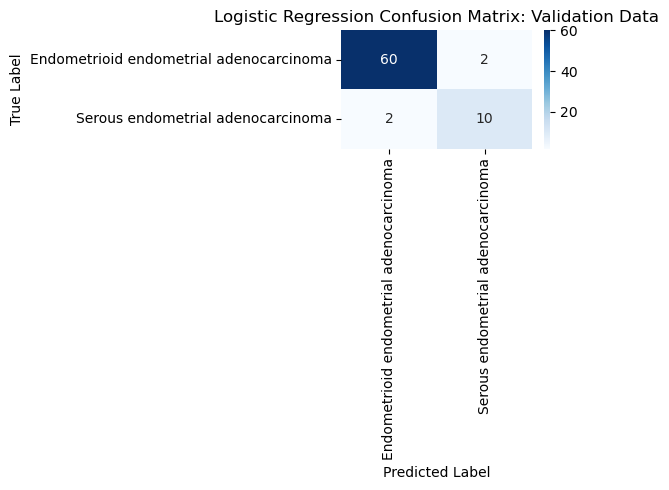


Decision Tree Results
---------------------
Training Accuracy: 1.000
Validation Accuracy: 0.797

Validation Classification Report:
                                         precision    recall  f1-score   support

Endometrioid endometrial adenocarcinoma       0.89      0.87      0.88        62
      Serous endometrial adenocarcinoma       0.38      0.42      0.40        12

                               accuracy                           0.80        74
                              macro avg       0.63      0.64      0.64        74
                           weighted avg       0.80      0.80      0.80        74



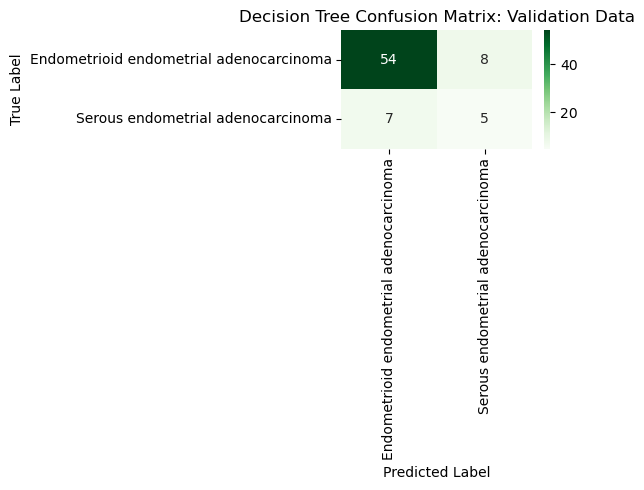

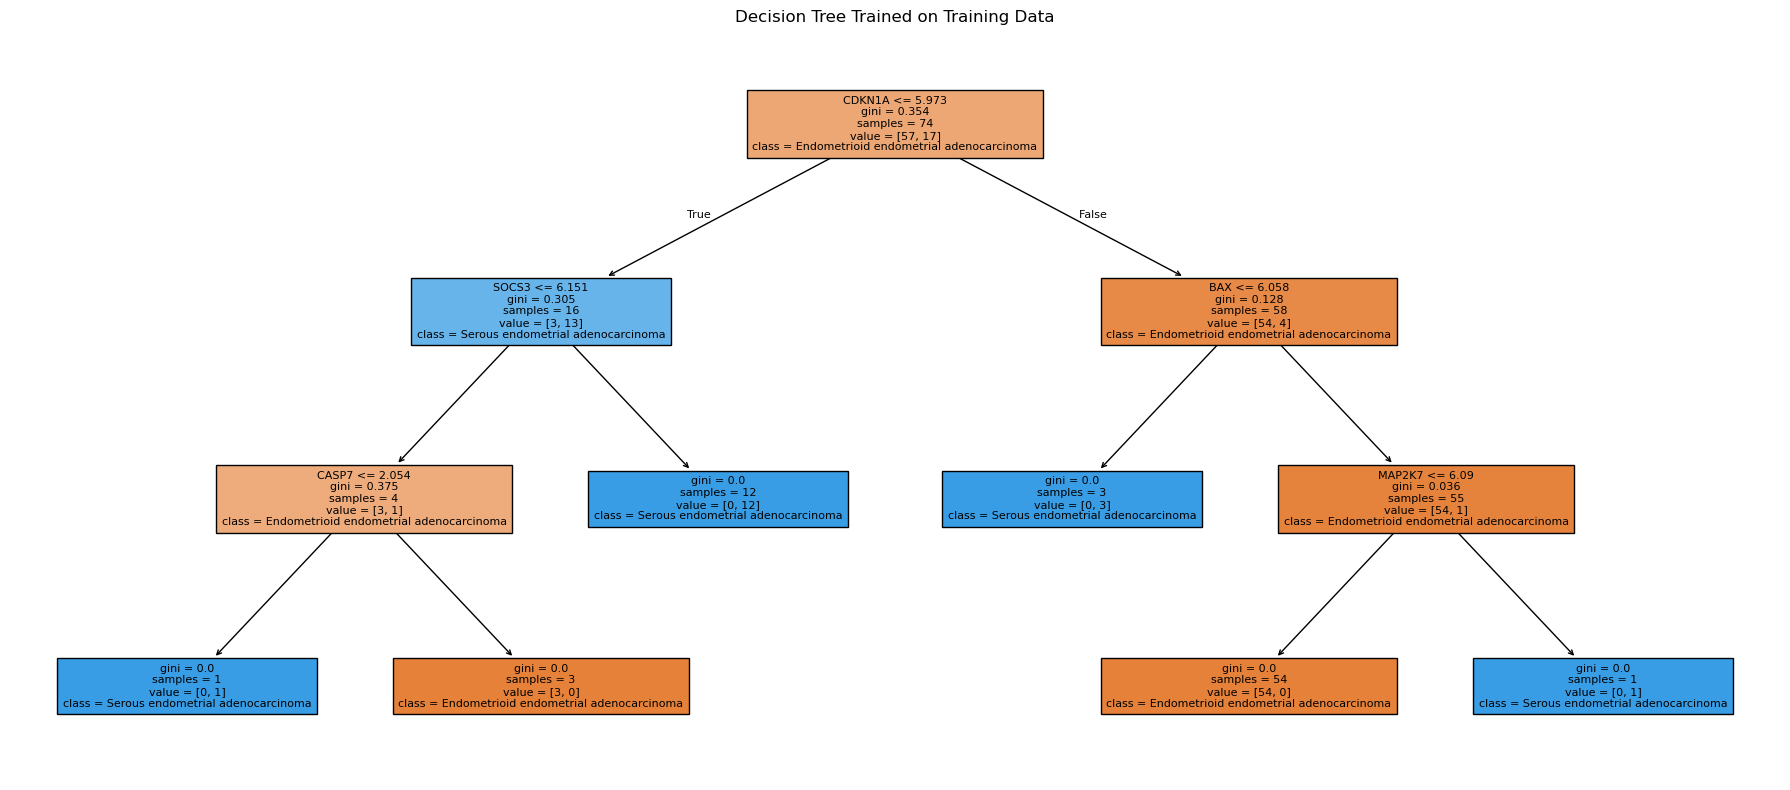

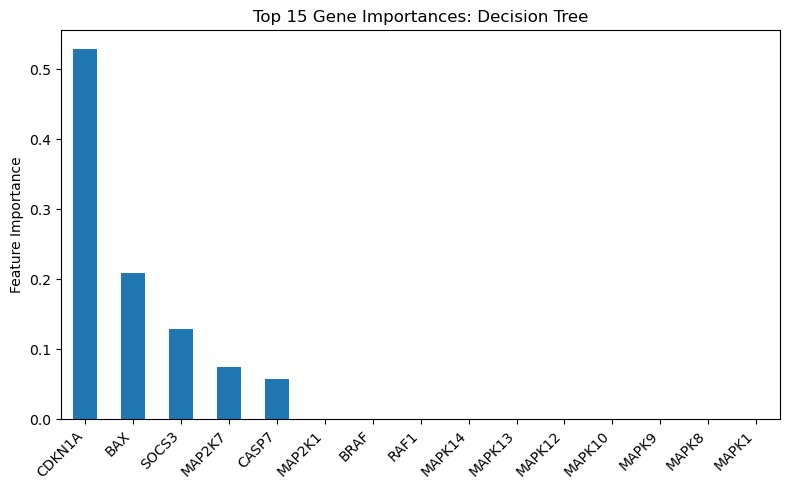

In [10]:
# Validation Modeling: Logistic Regression and Decision Tree 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

#  Load validation data
validation_data = pd.read_csv(
    '/Users/zain/Documents/GitHub/Module-4-Cancer-Imburgia-Abed/data/VALIDATION_SET_GSE62944_subsample_log2TPM.csv',
    #'/Users/ajq2af/OneDrive - University of Virginia/Documents/UVA/BME 2315/Module-4-Cancer-Imburgia-Abed/data/VALIDATION_SET_GSE62944_subsample_log2TPM.csv',
    index_col=0,
    header=0
)

validation_metadata = pd.read_csv(
    '/Users/zain/Documents/GitHub/Module-4-Cancer-Imburgia-Abed/data/VALIDATION_SET_GSE62944_metadata.csv',
    #'/Users/ajq2af/OneDrive - University of Virginia/Documents/UVA/BME 2315/Module-4-Cancer-Imburgia-Abed\data/VALIDATION_SET_GSE62944_metadata.csv',
    index_col=0,
    header=0
)

# Clean sample names 
data.columns = data.columns.str.strip()
metadata_df.index = metadata_df.index.str.strip()

validation_data.columns = validation_data.columns.str.strip()
validation_metadata.index = validation_metadata.index.str.strip()

#  Select cancer type 
cancer_type = 'UCEC'

# Training samples
train_samples = metadata_df[metadata_df['cancer_type'] == cancer_type].index
train_common_samples = data.columns.intersection(train_samples)

# Validation samples
val_samples = validation_metadata[validation_metadata['cancer_type'] == cancer_type].index
val_common_samples = validation_data.columns.intersection(val_samples)

#  Subset expression matrices to UCEC samples 
UCEC_train_data = data[train_common_samples]
UCEC_val_data = validation_data[val_common_samples]

#  Keep only genes available in BOTH training and validation data 
available_genes = [
    g for g in gene_list
    if g in UCEC_train_data.index and g in UCEC_val_data.index
]

print(f"Number of genes used in model: {len(available_genes)}")

#  Transpose so rows = samples, columns = genes 
train_gene_df = UCEC_train_data.loc[available_genes].T
val_gene_df = UCEC_val_data.loc[available_genes].T

#  Add metadata 
train_df = train_gene_df.join(metadata_df[['histologic_diagnosis']], how='left')
val_df = val_gene_df.join(validation_metadata[['histologic_diagnosis']], how='left')

#  Keep only Endometrioid and Serous samples 
target_classes = [
    'Endometrioid endometrial adenocarcinoma',
    'Serous endometrial adenocarcinoma'
]

train_df = train_df[train_df['histologic_diagnosis'].isin(target_classes)].copy()
val_df = val_df[val_df['histologic_diagnosis'].isin(target_classes)].copy()

#  Drop missing values 
train_df = train_df.dropna(subset=available_genes + ['histologic_diagnosis'])
val_df = val_df.dropna(subset=available_genes + ['histologic_diagnosis'])

#  Create X and y 
X_train = train_df[available_genes].values
X_val = val_df[available_genes].values

le = LabelEncoder()

y_train = le.fit_transform(train_df['histologic_diagnosis'])
y_val = le.transform(val_df['histologic_diagnosis'])

print("Class labels:", list(le.classes_))
print(f"Training samples: {X_train.shape[0]}")
print(f"Validation samples: {X_val.shape[0]}")

#  Standardize data for logistic regression 
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

#  Logistic Regression 
lr_model = LogisticRegression(
    penalty=None,
    max_iter=1000,
    random_state=0
)

lr_model.fit(X_train_scaled, y_train)

lr_train_pred = lr_model.predict(X_train_scaled)
lr_val_pred = lr_model.predict(X_val_scaled)

print("\nLogistic Regression Results")
print("---------------------------")
print(f"Training Accuracy: {accuracy_score(y_train, lr_train_pred):.3f}")
print(f"Validation Accuracy: {accuracy_score(y_val, lr_val_pred):.3f}")

print("\nValidation Classification Report:")
print(classification_report(y_val, lr_val_pred, target_names=le.classes_))

# Confusion matrix for logistic regression
lr_cm = confusion_matrix(y_val, lr_val_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    lr_cm,
    annot=True,
    fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap='Blues'
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Logistic Regression Confusion Matrix: Validation Data")
plt.tight_layout()
plt.show()

#  Decision Tree 
dt_model = DecisionTreeClassifier(
    max_depth=3,
    random_state=0
)

dt_model.fit(X_train, y_train)

dt_train_pred = dt_model.predict(X_train)
dt_val_pred = dt_model.predict(X_val)

print("\nDecision Tree Results")
print("---------------------")
print(f"Training Accuracy: {accuracy_score(y_train, dt_train_pred):.3f}")
print(f"Validation Accuracy: {accuracy_score(y_val, dt_val_pred):.3f}")

print("\nValidation Classification Report:")
print(classification_report(y_val, dt_val_pred, target_names=le.classes_))

# Confusion matrix for decision tree
dt_cm = confusion_matrix(y_val, dt_val_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    dt_cm,
    annot=True,
    fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap='Greens'
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Decision Tree Confusion Matrix: Validation Data")
plt.tight_layout()
plt.show()

#  Plot decision tree 
plt.figure(figsize=(18, 8))
plot_tree(
    dt_model,
    feature_names=available_genes,
    class_names=le.classes_,
    filled=True,
    fontsize=8
)
plt.title("Decision Tree Trained on Training Data")
plt.tight_layout()
plt.show()

#  Top decision tree features 
importances = pd.Series(dt_model.feature_importances_, index=available_genes)
top_features = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 5))
top_features.plot(kind='bar')
plt.title("Top 15 Gene Importances: Decision Tree")
plt.ylabel("Feature Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()




Simplified Decision Tree Results
---------------------------------
Training Accuracy:   0.932
Validation Accuracy: 0.770

Validation Classification Report:
                                         precision    recall  f1-score   support

Endometrioid endometrial adenocarcinoma       0.92      0.79      0.85        62
      Serous endometrial adenocarcinoma       0.38      0.67      0.48        12

                               accuracy                           0.77        74
                              macro avg       0.65      0.73      0.67        74
                           weighted avg       0.84      0.77      0.79        74



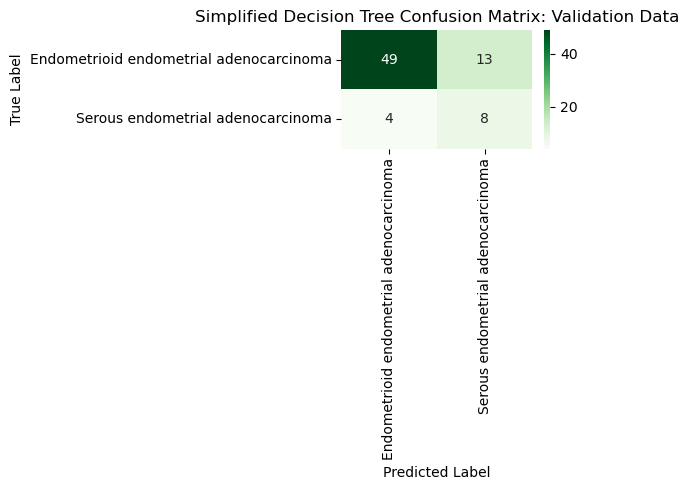

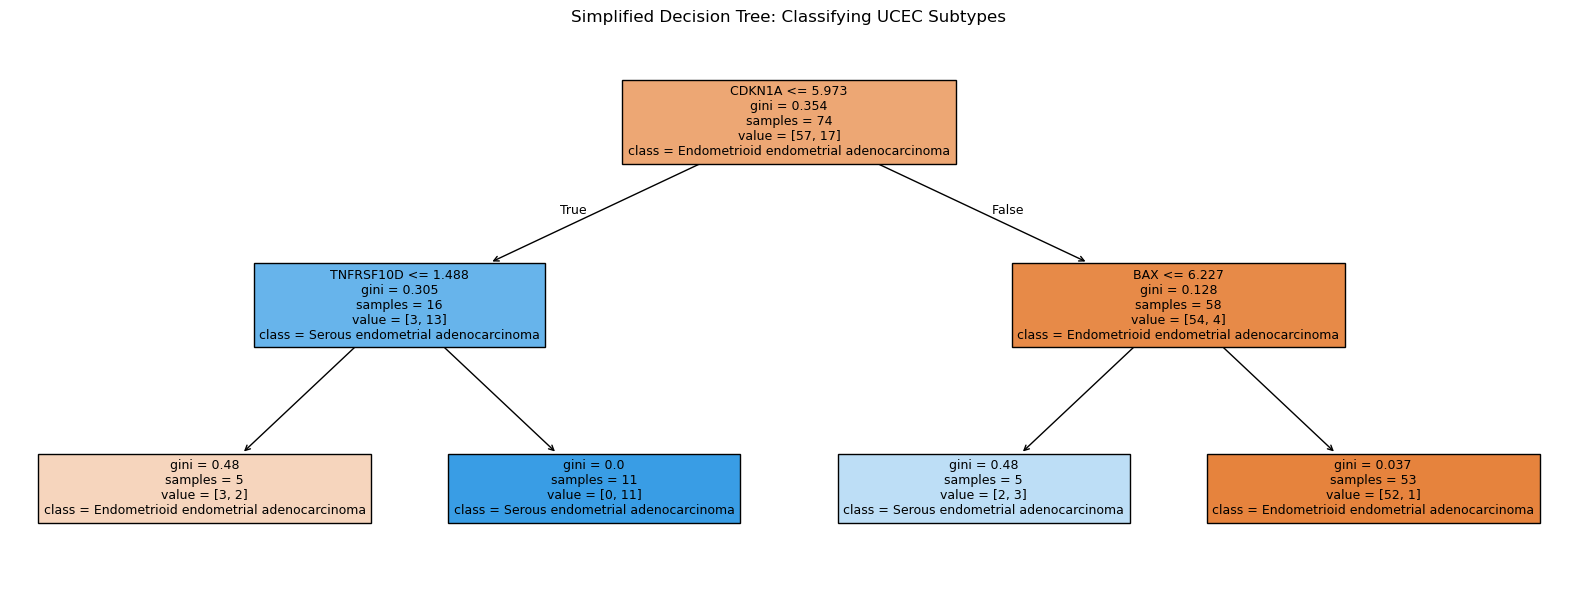

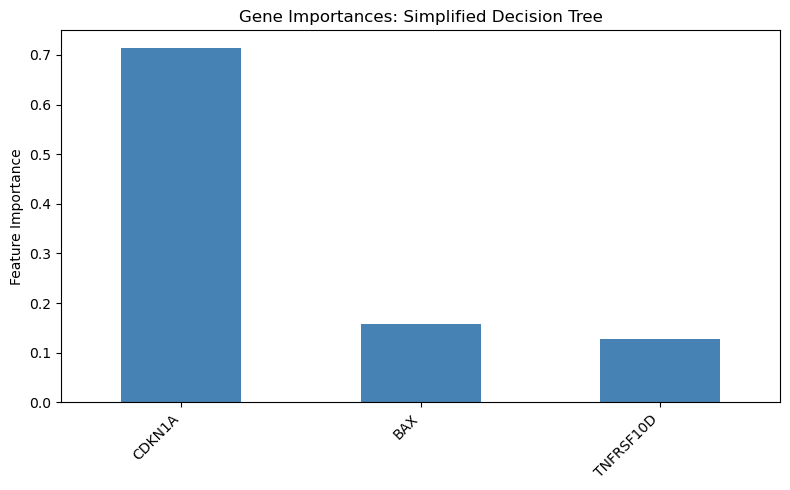


Leaf node gini scores:
  Leaf 2: gini = 0.480
  Leaf 3: gini = 0.000
  Leaf 5: gini = 0.480
  Leaf 6: gini = 0.037


In [11]:
dt_model_simple = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=10,
    min_samples_leaf=5,
    min_impurity_decrease=0.01,
    random_state=0
)

dt_model_simple.fit(X_train, y_train)

dt_train_pred = dt_model_simple.predict(X_train)
dt_val_pred = dt_model_simple.predict(X_val)

print("Simplified Decision Tree Results")
print("---------------------------------")
print(f"Training Accuracy:   {accuracy_score(y_train, dt_train_pred):.3f}")
print(f"Validation Accuracy: {accuracy_score(y_val, dt_val_pred):.3f}")

print("\nValidation Classification Report:")
print(classification_report(y_val, dt_val_pred, target_names=le.classes_))

# Confusion matrix
dt_cm_simple = confusion_matrix(y_val, dt_val_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    dt_cm_simple,
    annot=True,
    fmt='d',
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    cmap='Greens'
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Simplified Decision Tree Confusion Matrix: Validation Data")
plt.tight_layout()
plt.show()

# Plot the tree
plt.figure(figsize=(16, 6))
plot_tree(
    dt_model_simple,
    feature_names=available_genes,
    class_names=le.classes_,
    filled=True,
    fontsize=9
)
plt.title("Simplified Decision Tree: Classifying UCEC Subtypes")
plt.tight_layout()
plt.show()

# Feature importances
importances_simple = pd.Series(dt_model_simple.feature_importances_, index=available_genes)
top_features_simple = importances_simple[importances_simple > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 5))
top_features_simple.plot(kind='bar', color='steelblue')
plt.title("Gene Importances: Simplified Decision Tree")
plt.ylabel("Feature Importance")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Check leaf gini scores
print("\nLeaf node gini scores:")
for i, impurity in enumerate(dt_model_simple.tree_.impurity):
    if dt_model_simple.tree_.children_left[i] == -1:
        print(f"  Leaf {i}: gini = {impurity:.3f}")

Test samples — Endometrioid: 49, Serous: 26
Logistic Regression Accuracy (test set): 0.893
                                         precision    recall  f1-score   support

Endometrioid endometrial adenocarcinoma       0.94      0.90      0.92        49
      Serous endometrial adenocarcinoma       0.82      0.88      0.85        26

                               accuracy                           0.89        75
                              macro avg       0.88      0.89      0.88        75
                           weighted avg       0.90      0.89      0.89        75



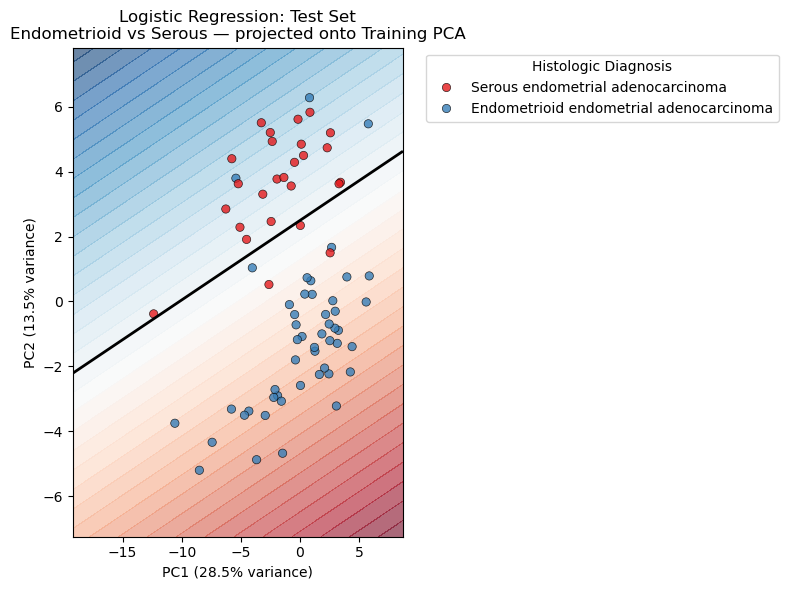

<Figure size 600x500 with 0 Axes>

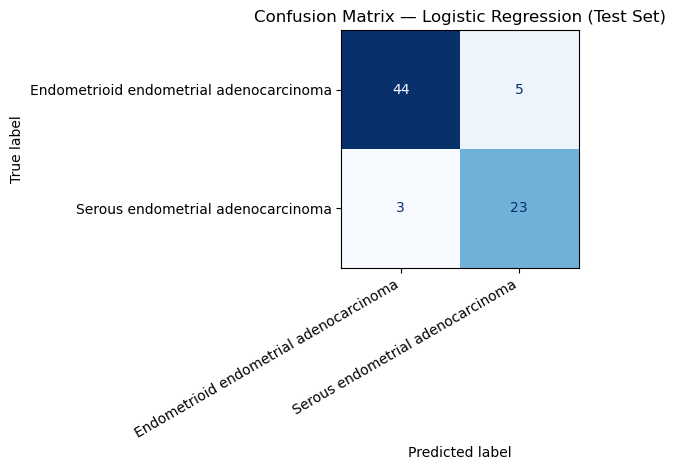

Decision Tree Accuracy (test set): 0.827
                                         precision    recall  f1-score   support

Endometrioid endometrial adenocarcinoma       0.82      0.94      0.88        49
      Serous endometrial adenocarcinoma       0.84      0.62      0.71        26

                               accuracy                           0.83        75
                              macro avg       0.83      0.78      0.79        75
                           weighted avg       0.83      0.83      0.82        75



<Figure size 600x500 with 0 Axes>

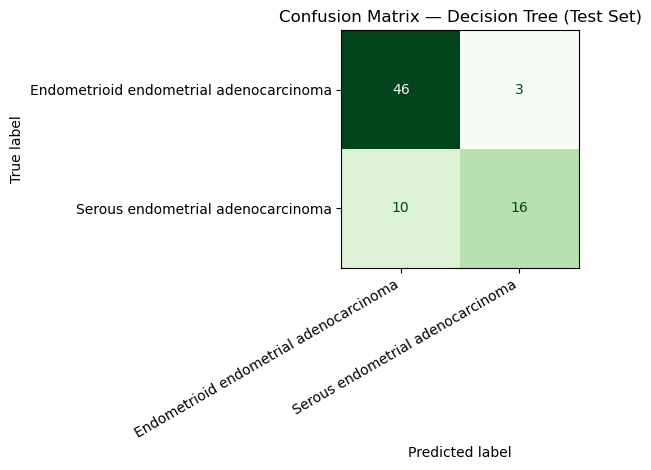

In [12]:
# %% ── EVALUATE ON TEST SET ───────────────────────────────────────────────────
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# ── Load test data ────────────────────────────────────────────────────────────
test_data = pd.read_csv(
    '/Users/zain/Documents/GitHub/Module-4-Cancer-Imburgia-Abed/data/TEST_SET_GSE62944_subsample_log2TPM.csv',
    #'/Users/ajq2af/OneDrive - University of Virginia/Documents/UVA/BME 2315/Module-4-Cancer-Imburgia-Abed/data/TEST_SET_GSE62944_subsample_log2TPM.csv',
    index_col=0, header=0
)
test_metadata = pd.read_csv(
    '/Users/zain/Documents/GitHub/Module-4-Cancer-Imburgia-Abed/data/TEST_SET_GSE62944_metadata.csv',
    #'/Users/ajq2af/OneDrive - University of Virginia/Documents/UVA/BME 2315/Module-4-Cancer-Imburgia-Abed/data/TEST_SET_GSE62944_metadata.csv',
    index_col=0, header=0
)

# ── Preprocess test data (mirror training steps) ──────────────────────────────
test_data.columns = test_data.columns.str.strip()
test_metadata.index = test_metadata.index.str.strip()

# Subset to UCEC samples
test_cancer_samples = test_metadata[test_metadata['cancer_type'] == cancer_type].index
test_common_samples = test_data.columns.intersection(test_cancer_samples)
UCEC_test_data = test_data[test_common_samples]

# Subset to gene list
test_gene_list = [g for g in desired_gene_list if g in UCEC_test_data.index]
UCEC_test_gene_data = UCEC_test_data.loc[test_gene_list]

# Merge with metadata
test_gene_df = UCEC_test_gene_data.T
UCEC_test_metadata = test_metadata.loc[test_common_samples]
UCEC_test_merged = test_gene_df.merge(UCEC_test_metadata, left_index=True, right_index=True)

# ── Filter to binary classification (same two subtypes as training) ────────────
test_binary_df = UCEC_test_merged[
    UCEC_test_merged['histologic_diagnosis'].isin([
        'Endometrioid endometrial adenocarcinoma',
        'Serous endometrial adenocarcinoma'
    ])
].copy()

# ── Use only genes present in BOTH training and test sets ────────────────────
# (available_genes was defined during training)
test_available_genes = [g for g in available_genes if g in test_binary_df.columns]
if test_available_genes != available_genes:
    print(f"Warning: {len(available_genes) - len(test_available_genes)} training genes missing from test set.")

X_test_all = test_binary_df[test_available_genes].values

# Encode labels using the SAME LabelEncoder fitted on training data
y_test = le.transform(test_binary_df['histologic_diagnosis'])
y_test_label = list(test_binary_df['histologic_diagnosis'])
print(f"Test samples — Endometrioid: {(y_test==0).sum()}, Serous: {(y_test==1).sum()}")

# ── Logistic Regression: evaluate on test set ─────────────────────────────────
# Use the SAME scaler fitted on training data (no refit!)
X_test_scaled = scaler.transform(X_test_all)

lr_test_acc = lr_model.score(X_test_scaled, y_test)
print(f"Logistic Regression Accuracy (test set): {lr_test_acc:.3f}")
print(classification_report(y_test, lr_model.predict(X_test_scaled), target_names=le.classes_))

# Project test data onto training PCA for visualization
X_test_vis = pca_vis.transform(X_test_all)

# Decision boundary + test scatter
Z_test = lr_model.decision_function(grid_scaled).reshape(xx.shape)  # grid already computed

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z_test, levels=50, cmap="RdBu", alpha=0.6)
plt.contour(xx, yy, Z_test, levels=[0], colors='black', linewidths=2)
sns.scatterplot(
    x=X_test_vis[:, 0],
    y=X_test_vis[:, 1],
    hue=y_test_label,
    edgecolors='k',
    palette="Set1",
    alpha=0.8
)
plt.xlabel(f"PC1 ({explained_vis[0]:.1f}% variance)")
plt.ylabel(f"PC2 ({explained_vis[1]:.1f}% variance)")
plt.title("Logistic Regression: Test Set\nEndometrioid vs Serous — projected onto Training PCA")
plt.legend(title="Histologic Diagnosis", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Confusion matrix — Logistic Regression
cm_lr = confusion_matrix(y_test, lr_model.predict(X_test_scaled))
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=le.classes_)
plt.figure(figsize=(6, 5))
disp_lr.plot(cmap='Blues', colorbar=False)
plt.title("Confusion Matrix — Logistic Regression (Test Set)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# ── Decision Tree: evaluate on test set ───────────────────────────────────────
# Align test features to training gene order (fill missing with 0 if any)
X_test_dt = test_binary_df.reindex(columns=available_genes, fill_value=0).values

dt_test_acc = dt_model.score(X_test_dt, y_test)
print(f"Decision Tree Accuracy (test set): {dt_test_acc:.3f}")
print(classification_report(y_test, dt_model.predict(X_test_dt), target_names=le.classes_))

# Confusion matrix — Decision Tree
cm_dt = confusion_matrix(y_test, dt_model.predict(X_test_dt))
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=le.classes_)
plt.figure(figsize=(6, 5))
disp_dt.plot(cmap='Greens', colorbar=False)
plt.title("Confusion Matrix — Decision Tree (Test Set)")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

The decision tree splits data at each node by choosing the gene that best separates Endometrioid from Serous samples. Importance is calculated as the weighted reduction in "impurity" (Gini impurity by default) that each gene contributes across all the splits it's used in.

The logistic regression model performed better than the decision tree when applied to the validation dataset. Using 101 apoptosis-related genes, logistic regression achieved a validation accuracy of 94.6%, correctly classifying 60 of 62 endometrioid samples and 10 of 12 serous samples. This suggests that apoptosis-related gene expression patterns contain meaningful information for distinguishing UCEC histologic subtypes. In contrast, the decision tree achieved a lower validation accuracy of 79.7% and correctly identified only 5 of 12 serous tumors. Although the decision tree highlighted genes such as CDKN1A, BAX, SOCS3, MAP2K7, and CASP7 as important features, its weaker validation performance suggests that simple cutoff-based rules may not generalize as well as logistic regression. Overall, the validation results support the conclusion that apoptosis-related molecular profiles differ between endometrioid and serous UCEC, but the models should be interpreted as exploratory rather than clinically predictive.

Both models showed some signs of overfitting because they achieved 100% accuracy on the training data. However, the amount of overfitting differed between models. The logistic regression model only dropped slightly to 94.6% validation accuracy, suggesting that it generalized well overall. In contrast, the decision tree dropped to 79.7% validation accuracy, showing stronger evidence of overfitting. This means the decision tree likely learned patterns that were too specific to the training data and did not perform as well on new validation samples.

For the logistic regression model, the training accuracy was 1.000, so the in-sample error was 0.000, or 0%. The validation accuracy was 0.946, so the out-of-sample error was 0.054, or 5.4%. This small increase in error suggests that the logistic regression model generalizes well to the validation data, although the perfect training accuracy still suggests slight overfitting.

For the decision tree model, the training accuracy was also 1.000, so the in-sample error was 0.000, or 0%. However, the validation accuracy was 0.797, so the out-of-sample error was 0.203, or 20.3%. This much larger increase from in-sample to out-of-sample error shows that the decision tree is more overfit than the logistic regression model. The decision tree learned the training data perfectly but made more mistakes on new validation samples.

## Data Analysis: 

### Methods
The machine learning technique I am using is: Classifiication because we are looking at gene effects on a finite group of histological status of tumors

*What is this method optimizing? How does the model decide it is "good enough"?*

**

### Analysis
*(Describe how you analyzed the data. This is where you should intersperse your Python code so that anyone reading this can run your code to perform the analysis that you did, generate your figures, etc.)*

## Verify and validate your analysis: 
*Pick a SPECIFIC metric to determine how well your model is performing and describe how it works here.*

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## Limitations and Future Work: 
*(Think about the answer your analysis generated, draw conclusions related to your overarching question, and discuss the ethical implications of your conclusions.*

## NOTES FROM YOUR TEAM: 
*This is where our team is taking notes and recording activity.*

## QUESTIONS FOR YOUR TA: 
*These are questions we have for our TA.*